In [15]:

import polars as plr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:
filepath='/Volumes/SSK Drive /supermarket/ECommerce_consumer behaviour.csv'

ddf=plr.scan_csv(filepath)



In [28]:
user_features = ddf.group_by("user_id").agg([
   plr.col("order_number").max().alias("total_orders"),
   plr.col("add_to_cart_order").max().mean().alias("user_avg_basket_size"),
   plr.col("days_since_prior_order").mean().alias("avg_days_between_orders")
])

# 4. Apply the segmentation logic directly to those calculated features
segmented_users_lazy = user_features.with_columns([
    
    # Frequency Cohorts
   plr.when(plr.col("total_orders") >= 30).then(plr.lit("VIP Loyalists"))
      .when(plr.col("total_orders") >= 10).then(plr.lit("Regulars"))
      .when(plr.col("total_orders") > 1).then(plr.lit("Occasional Shoppers"))
      .otherwise(plr.lit("One-Time Buyers")).alias("Frequency_Segment"),
    
    # Volume Cohorts
   plr.when(plr.col("user_avg_basket_size") >= 20).then(plr.lit("Bulk/Family Buyers"))
      .when(plr.col("user_avg_basket_size") >= 5).then(plr.lit("Standard Shoppers"))
      .otherwise(plr.lit("Quick Trippers")).alias("Basket_Segment"),
      
    # Churn Risk
   plr.when(plr.col("avg_days_between_orders") > 21).then(plr.lit("High Churn Risk"))
      .when(plr.col("avg_days_between_orders") > 14).then(plr.lit("At Risk"))
      .otherwise(plr.lit("Healthy")).alias("Retention_Status")
])

# 5. Trigger the single execution for the entire process
print("Crunching the raw data and building segments...")
final_segments = segmented_users_lazy

# View the final output
print(final_segments.head())

Crunching the raw data and building segments...
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SLICE[offset: 0, len: 5]
   WITH_COLUMNS:
   [when([(col("total_orders")) >= (30)]).then("VIP Loyalists").otherwise(when([(col("total_orders")) >= (10)]).then("Regulars").otherwise(when([(col("total_orders")) > (1)]).then("Occasional Shoppers").otherwise("One-Time Buyers"))).alias("Frequency_Segment"), when([(col("user_avg_basket_size")) >= (20.0)]).then("Bulk/Family Buyers").otherwise(when([(col("user_avg_basket_size")) >= (5.0)]).then("Standard Shoppers").otherwise("Quick Trippers")).alias("Basket_Segment"), when([(col("avg_days_between_orders")) > (21.0)]).then("High Churn Risk").otherwise(when([(col("avg_days_between_orders")) > (14.0)]).then("At Risk").otherwise("Healthy")).alias("Retention_Status")] 
    AGGREGATE[maintain_order: false]
      [col("order_number").max().alias("total_orders"), col("add_to_cart_order").max().mean().alias("user_avg_basket_siz

In [31]:
product_features = ddf.group_by("product_id").agg([
    plr.col("order_id").count().alias("times_purchased"),
    plr.col("add_to_cart_order").mean().alias("avg_cart_position"),
    (plr.col("reordered").sum() / plr.col("reordered").count()).alias("product_reorder_probability")
])

# 2. Define temporal_features
temporal_features = ddf.group_by(["order_dow", "order_hour_of_day"]).agg([
    plr.col("order_id").n_unique().alias("total_traffic"),
    plr.col("product_id").count().alias("items_sold")
])

# 3. Now these assignments will work perfectly!
final_product_df = product_features
final_temporal_df = temporal_features

print("Product and Temporal features calculated successfully!")

Product and Temporal features calculated successfully!


In [32]:
print("Executing Polars pipeline across CPU cores...")

# .collect() pulls the summarized data into memory
final_user_df = user_features
final_product_df = product_features
final_temporal_df = temporal_features

# Save these summaries locally so we don't have to touch the 2-million row file again
final_user_df.sink_csv("extracted_user_features.csv")
final_product_df.sink_csv("extracted_product_features.csv")
final_temporal_df.sink_csv("extracted_temporal_features.csv")
print("Data successfully extracted and saved locally!")


Executing Polars pipeline across CPU cores...
Data successfully extracted and saved locally!


In [34]:
print(product_features.head().collect())

shape: (5, 4)
┌────────────┬─────────────────┬───────────────────┬─────────────────────────────┐
│ product_id ┆ times_purchased ┆ avg_cart_position ┆ product_reorder_probability │
│ ---        ┆ ---             ┆ ---               ┆ ---                         │
│ i64        ┆ u32             ┆ f64               ┆ f64                         │
╞════════════╪═════════════════╪═══════════════════╪═════════════════════════════╡
│ 3          ┆ 28639           ┆ 9.679633          ┆ 0.599916                    │
│ 45         ┆ 18735           ┆ 8.445637          ┆ 0.572778                    │
│ 9          ┆ 13771           ┆ 10.283204         ┆ 0.474621                    │
│ 18         ┆ 1059            ┆ 7.671388          ┆ 0.640227                    │
│ 24         ┆ 226039          ┆ 7.160176          ┆ 0.718261                    │
└────────────┴─────────────────┴───────────────────┴─────────────────────────────┘


In [35]:
users_df= plr.read_csv("extracted_user_features.csv")
basket_99th = users_df.select(plr.col("user_avg_basket_size").quantile(0.99)).item()
orders_99th = users_df.select(plr.col("total_orders").quantile(0.99)).item()
print(f"99% of customers buy fewer than {basket_99th:.1f} items per cart.")
print(f"99% of customers have placed fewer than {orders_99th:.0f} total orders.\n")

99% of customers buy fewer than 38.0 items per cart.
99% of customers have placed fewer than 86 total orders.



In [37]:
whales = users_df.filter(
    (plr.col("user_avg_basket_size") > basket_99th) | 
    (plr.col("total_orders") > orders_99th)
)

print(f"⚠️ Found {whales.height} potential bots, wholesale buyers, or glitches.")
print(whales.select(["user_id", "total_orders", "user_avg_basket_size"]).head(), "\n")

⚠️ Found 1927 potential bots, wholesale buyers, or glitches.
shape: (5, 3)
┌─────────┬──────────────┬──────────────────────┐
│ user_id ┆ total_orders ┆ user_avg_basket_size │
│ ---     ┆ ---          ┆ ---                  │
│ i64     ┆ i64          ┆ f64                  │
╞═════════╪══════════════╪══════════════════════╡
│ 62443   ┆ 93           ┆ 15.0                 │
│ 191517  ┆ 7            ┆ 44.0                 │
│ 149835  ┆ 89           ┆ 17.0                 │
│ 166743  ┆ 32           ┆ 92.0                 │
│ 187712  ┆ 13           ┆ 51.0                 │
└─────────┴──────────────┴──────────────────────┘ 



In [39]:
correlation_matrix = users_df.select([
    "total_orders", 
    "user_avg_basket_size", 
    "avg_days_between_orders"
]).drop_nulls().corr()

print(correlation_matrix)

shape: (3, 3)
┌──────────────┬──────────────────────┬─────────────────────────┐
│ total_orders ┆ user_avg_basket_size ┆ avg_days_between_orders │
│ ---          ┆ ---                  ┆ ---                     │
│ f64          ┆ f64                  ┆ f64                     │
╞══════════════╪══════════════════════╪═════════════════════════╡
│ 1.0          ┆ 0.191867             ┆ -0.398544               │
│ 0.191867     ┆ 1.0                  ┆ -0.044959               │
│ -0.398544    ┆ -0.044959            ┆ 1.0                     │
└──────────────┴──────────────────────┴─────────────────────────┘


In [43]:
# 1. Apply the text tags to the eager dataframe you already have in memory
segmented_eager = users_df.with_columns([
   plr.when(plr.col("total_orders") >= 30).then(plr.lit("VIP Loyalists"))
      .when(plr.col("total_orders") >= 10).then(plr.lit("Regulars"))
      .when(plr.col("total_orders") > 1).then(plr.lit("Occasional Shoppers"))
      .otherwise(plr.lit("One-Time Buyers")).alias("Frequency_Segment")
])

# 2. Group and count the segments using .len() 
segment_counts = segmented_eager.group_by("Frequency_Segment").len()

# 3. Calculate the exact percentage breakdown
total_users = segmented_eager.height
segment_percentages = segment_counts.with_columns(
    (plr.col("len") / total_users * 100).round(2).alias("Percentage_%")
)

print(segment_percentages)

shape: (4, 3)
┌─────────────────────┬───────┬──────────────┐
│ Frequency_Segment   ┆ len   ┆ Percentage_% │
│ ---                 ┆ ---   ┆ ---          │
│ str                 ┆ u32   ┆ f64          │
╞═════════════════════╪═══════╪══════════════╡
│ VIP Loyalists       ┆ 17096 ┆ 16.24        │
│ Regulars            ┆ 36038 ┆ 34.23        │
│ One-Time Buyers     ┆ 6355  ┆ 6.04         │
│ Occasional Shoppers ┆ 45784 ┆ 43.49        │
└─────────────────────┴───────┴──────────────┘


In [54]:
# !pip install imbalanced-learn

import polars as plr
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Prepare the Data (Dropping any missing values first)
clean_df = segmented_eager.drop_nulls()

# We isolate our numerical features (X) and our target text labels (y)
X_polars = clean_df.select(["total_orders", "user_avg_basket_size", "avg_days_between_orders"])
y_polars = clean_df.select("Frequency_Segment")

X = X_polars.to_numpy()
y = y_polars.to_series().to_list()

print(f"📉 BEFORE SMOTE (Imbalanced):")
for segment, count in Counter(y).items():
    print(f"   {segment}: {count} users")

# 2. Initialize and apply SMOTE
print("\n⚙️ Synthesizing new data points to balance the scales...")
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# 3. View the Results
print("\n⚖️ AFTER SMOTE (Perfectly Balanced):")
for segment, count in Counter(y_balanced).items():
    print(f"   {segment}: {count} users")

📉 BEFORE SMOTE (Imbalanced):
   Occasional Shoppers: 45784 users
   Regulars: 36038 users
   VIP Loyalists: 17096 users

⚙️ Synthesizing new data points to balance the scales...

⚖️ AFTER SMOTE (Perfectly Balanced):
   Occasional Shoppers: 45784 users
   Regulars: 45784 users
   VIP Loyalists: 45784 users


🧠 Training Random Forest on imbalanced data...
📈 Generating ROC Chart...


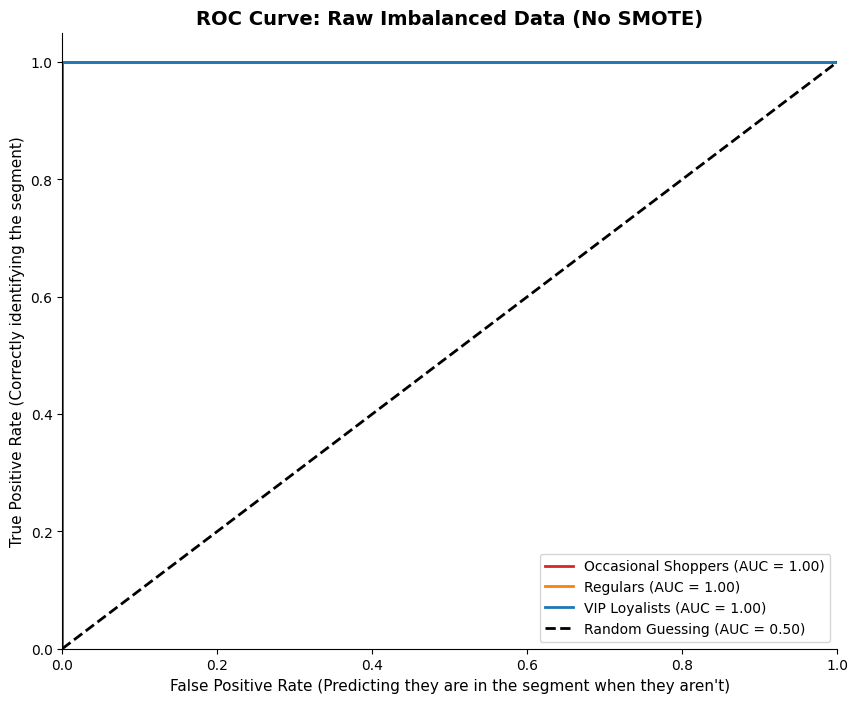

In [55]:
import polars as plr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# 1. Prepare Data (Imbalanced, NO SMOTE)
clean_df = segmented_eager.drop_nulls()

X_polars = clean_df.select(["total_orders", "user_avg_basket_size", "avg_days_between_orders"])
y_polars = clean_df.select("Frequency_Segment")

X = X_polars.to_numpy()
y_strings = y_polars.to_series().to_list()

# 2. Binarize labels to handle 4 distinct categories (One-vs-Rest)
lb = LabelBinarizer()
y_bin = lb.fit_transform(y_strings)
classes = lb.classes_

# 3. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

# 4. Train the Random Forest
print("🧠 Training Random Forest on imbalanced data...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict Probabilities instead of absolute classes
# (ROC curves require the percentage confidence of a guess)
y_score = rf_model.predict_proba(X_test)

# Convert the list of arrays from Scikit-Learn into a clean matrix
y_score_matrix = np.array([y_score[i][:, 1] for i in range(len(classes))]).T

# 6. Plot the ROC Curves
plt.figure(figsize=(10, 8))
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c'] # Distinct colors for 4 classes

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score_matrix[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, 
             label=f'{classes[i]} (AUC = {roc_auc:.2f})')

# Draw the 50/50 guessing line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.50)')

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Predicting they are in the segment when they aren\'t)', fontsize=11)
plt.ylabel('True Positive Rate (Correctly identifying the segment)', fontsize=11)
plt.title('ROC Curve: Raw Imbalanced Data (No SMOTE)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

print("📈 Generating ROC Chart...")
plt.show()

In [2]:
import polars as plr

# 1. Load the features you saved to your hard drive earlier
users_df = plr.read_csv("extracted_user_features.csv")

# 2. Re-apply the marketing text tags and save it as our "segmented_eager" variable
segmented_eager = users_df.with_columns([
   plr.when(plr.col("total_orders") >= 30).then(plr.lit("VIP Loyalists"))
      .when(plr.col("total_orders") >= 10).then(plr.lit("Regulars"))
      .when(plr.col("total_orders") > 1).then(plr.lit("Occasional Shoppers"))
      .otherwise(plr.lit("One-Time Buyers")).alias("Frequency_Segment")
])

print("✅ Data loaded and tagged successfully!")

# ... (You can paste the rest of the SMOTE / Machine Learning code directly below this) ...

✅ Data loaded and tagged successfully!


In [3]:
import polars as plr
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

# 1. Prepare the Data (Dropping nulls)
clean_df = segmented_eager.drop_nulls()

# ⚠️ THE FIX: Notice we completely removed "total_orders" from X!
X_polars = clean_df.select(["user_avg_basket_size", "avg_days_between_orders"])
y_polars = clean_df.select("Frequency_Segment")

X = X_polars.to_numpy()
y = y_polars.to_series().to_list()

# 2. Split the data FIRST (Never use SMOTE on your testing data!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"📉 Imbalanced Training Data: {Counter(y_train)}")

# 3. Apply SMOTE only to the Training Data
print("⚙️ Applying SMOTE to balance the training scales...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"⚖️ Balanced Training Data: {Counter(y_train_smote)}")

# 4. Train the Random Forest on the Balanced Data
print("🧠 Training the Random Forest (without the cheat sheet)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# 5. Take the Final Test
y_pred = rf_model.predict(X_test)

# 6. View the Real Results
print("\n" + "="*50)
print(f"🎯 REAL ACCURACY SCORE: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("="*50)
print("\nDetailed Breakdown by Segment:")
print(classification_report(y_test, y_pred))

📉 Imbalanced Training Data: Counter({'Occasional Shoppers': 32049, 'Regulars': 25226, 'VIP Loyalists': 11967})
⚙️ Applying SMOTE to balance the training scales...
⚖️ Balanced Training Data: Counter({'VIP Loyalists': 32049, 'Regulars': 32049, 'Occasional Shoppers': 32049})
🧠 Training the Random Forest (without the cheat sheet)...

🎯 REAL ACCURACY SCORE: 57.82%

Detailed Breakdown by Segment:
                     precision    recall  f1-score   support

Occasional Shoppers       0.64      0.81      0.72     13735
           Regulars       0.48      0.32      0.38     10812
      VIP Loyalists       0.51      0.51      0.51      5129

           accuracy                           0.58     29676
          macro avg       0.54      0.55      0.53     29676
       weighted avg       0.56      0.58      0.56     29676

